<a href="https://colab.research.google.com/github/kalpatapusridatta-27/Robust-Spam-Message-Classifier/blob/main/robust_spam_message_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load dataset (using raw link for convenience)
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
df['label_num'] = df.label.map({'ham': 0, 'spam': 1})

In [2]:
def inject_noise(text, substitution_rate=0.1):
    """Randomly adds typos or character perturbations to the text."""
    chars = "abcdefghijklmnopqrstuvwxyz"
    words = text.split()
    noisy_words = []

    for word in words:
        if random.random() < substitution_rate and len(word) > 3:
            # Simple perturbation: swap a char or add a random typo
            idx = random.randint(0, len(word)-1)
            word = word[:idx] + random.choice(chars) + word[idx+1:]
        noisy_words.append(word)
    return " ".join(noisy_words)

# Create a 'noisy' version of our test set later for stress-testing

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label_num'], test_size=0.2, random_state=42)

# TF-IDF Vectorization
# We use sublinear_tf=True to scale the word counts logarithmically, reducing the impact of very long messages
vectorizer = TfidfVectorizer(stop_words='english', sublinear_tf=True, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [5]:
# This block defines X_train, X_test, y_train, and y_test
from sklearn.model_selection import train_test_split

# Ensure 'df' was loaded in step 1, then split:
X_train, X_test, y_train, y_test = train_test_split(
    df['message'],
    df['label_num'],
    test_size=0.2,
    random_state=42
)

print(f"Data split successfully! Training samples: {len(X_train)}")

Data split successfully! Training samples: 4457


In [8]:
# 1. Initialize the vectorizer
vectorizer = TfidfVectorizer(stop_words='english', sublinear_tf=True, ngram_range=(1, 2))

# 2. FIT and TRANSFORM the training data (The 'Learning' step)
X_train_tfidf = vectorizer.fit_transform(X_train)

# 3. TRANSFORM the clean test data (Using what it learned)
X_test_tfidf = vectorizer.transform(X_test)

# 4. TRANSFORM the noisy test data (The Stress Test)
X_test_noisy = X_test.apply(lambda x: inject_noise(x, substitution_rate=0.2))
X_test_noisy_tfidf = vectorizer.transform(X_test_noisy)

print("Vectorizer successfully fitted and data transformed!")

Vectorizer successfully fitted and data transformed!


In [9]:
# Initialize and Train
model = LogisticRegression(solver='liblinear', class_weight='balanced')
model.fit(X_train_tfidf, y_train)

print("Model training complete.")

Model training complete.


In [10]:
from sklearn.metrics import classification_report

# Predictions
clean_preds = model.predict(X_test_tfidf)
noisy_preds = model.predict(X_test_noisy_tfidf)

print("--- PERFORMANCE ON CLEAN DATA ---")
print(classification_report(y_test, clean_preds))

print("\n--- PERFORMANCE ON NOISY DATA (Adversarial Stress Test) ---")
print(classification_report(y_test, noisy_preds))

--- PERFORMANCE ON CLEAN DATA ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.94      0.96      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.98      0.97      1115
weighted avg       0.99      0.99      0.99      1115


--- PERFORMANCE ON NOISY DATA (Adversarial Stress Test) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.94      0.95      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.98      0.98      0.98      1115



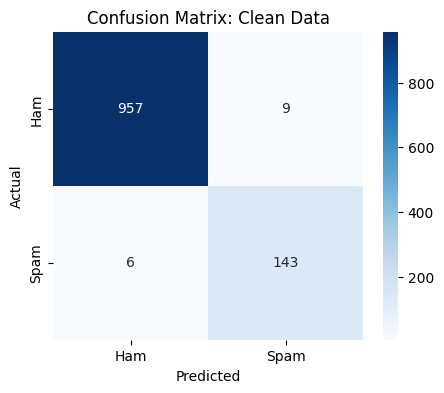

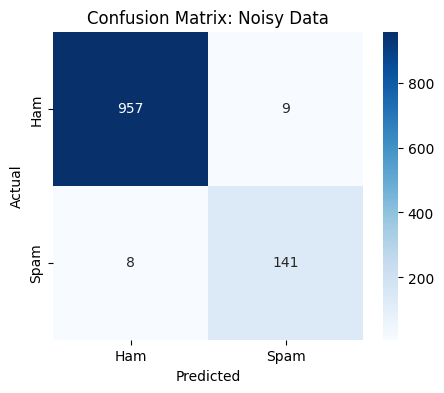

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_cm(y_test, clean_preds, "Confusion Matrix: Clean Data")
plot_cm(y_test, noisy_preds, "Confusion Matrix: Noisy Data")

In [12]:
# Get the coefficients from the model
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Create a dataframe for visualization
features_df = pd.DataFrame({'word': feature_names, 'coefficient': coefficients})
top_spam_words = features_df.sort_values(by='coefficient', ascending=False).head(10)

print("Top 10 Predictors for SPAM:")
print(top_spam_words)

Top 10 Predictors for SPAM:
         word  coefficient
28184     txt     4.944424
17919  mobile     4.301472
10175    free     4.283004
5565    claim     4.095703
30829     www     3.987247
25463    stop     3.862297
28323      uk     3.852639
22471   reply     3.843126
26507    text     3.814344
666      150p     3.181585


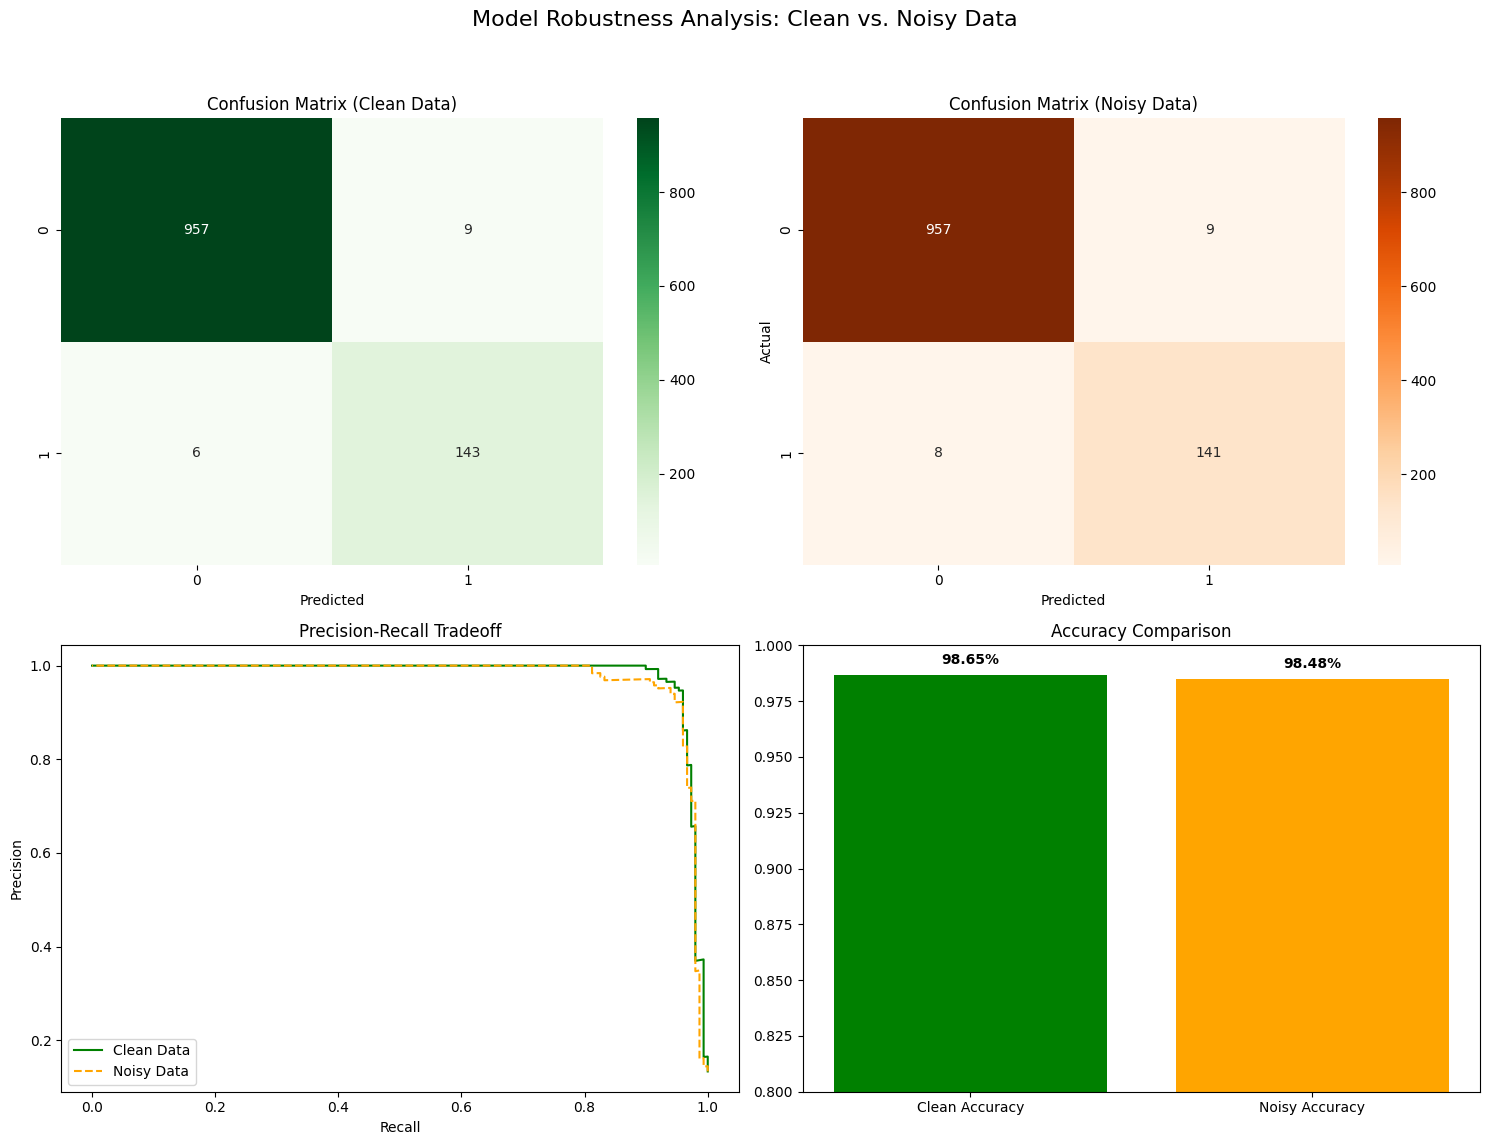

Image 'spam_classifier_robustness_results.png' has been saved to your Colab files.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve

# Create a figure with two rows of visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Robustness Analysis: Clean vs. Noisy Data', fontsize=16)

# 1. Confusion Matrix - Clean Data
cm_clean = confusion_matrix(y_test, clean_preds)
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Greens', ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix (Clean Data)')
axes[0, 0].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# 2. Confusion Matrix - Noisy Data
cm_noisy = confusion_matrix(y_test, noisy_preds)
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix (Noisy Data)')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# 3. Precision-Recall Curve
# Clean Data
precision_c, recall_c, _ = precision_recall_curve(y_test, model.predict_proba(X_test_tfidf)[:,1])
axes[1, 0].plot(recall_c, precision_c, label='Clean Data', color='green')
# Noisy Data
precision_n, recall_n, _ = precision_recall_curve(y_test, model.predict_proba(X_test_noisy_tfidf)[:,1])
axes[1, 0].plot(recall_n, precision_n, label='Noisy Data', color='orange', linestyle='--')

axes[1, 0].set_title('Precision-Recall Tradeoff')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()

# 4. Accuracy Comparison Bar Chart
accuracies = [accuracy_score(y_test, clean_preds), accuracy_score(y_test, noisy_preds)]
labels = ['Clean Accuracy', 'Noisy Accuracy']
axes[1, 1].bar(labels, accuracies, color=['green', 'orange'])
axes[1, 1].set_ylim(0.8, 1.0) # Zoom in to see the small difference
axes[1, 1].set_title('Accuracy Comparison')
for i, v in enumerate(accuracies):
    axes[1, 1].text(i, v + 0.005, f"{v:.2%}", ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# SAVE THE IMAGE OUTPUT
plt.savefig('spam_classifier_robustness_results.png', dpi=300)
plt.show()

print("Image 'spam_classifier_robustness_results.png' has been saved to your Colab files.")